In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import time
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 设置随机种子保证结果可复现
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用设备: {device}")

当前使用设备: cuda


原始数据形状: (17856, 170, 3)


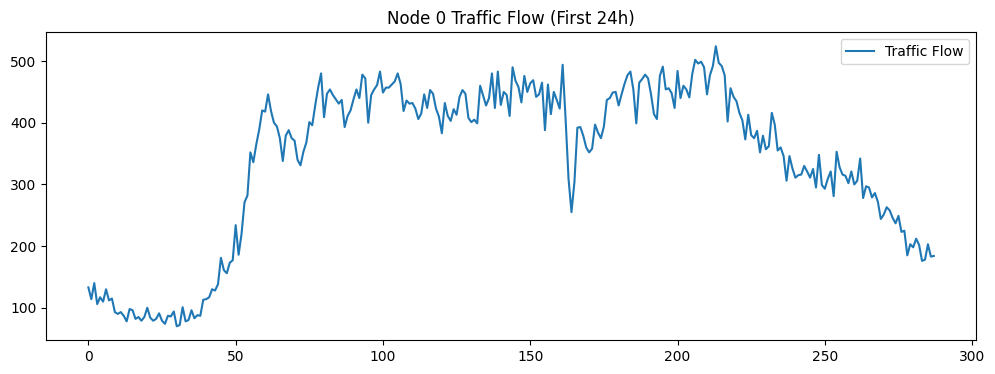

In [2]:
raw_data = np.load('traffic-flow/traffic.npz')['data'] 
print(f"原始数据形状: {raw_data.shape}") # 预期: [总时间步, 节点数, 3]

# 为了演示，我们先提取第 0 个节点的流量、拥挤、车速数据
# 如果你要做全节点预测，则需要 reshape 为 (T, N*F)
node_data = raw_data[:, 0, :] 

# 数据可视化：查看前288个时间步（通常是一天的数据量）
plt.figure(figsize=(12, 4))
plt.plot(node_data[:288, 0], label='Traffic Flow')
plt.title("Node 0 Traffic Flow (First 24h)")
plt.legend() 
plt.show()

In [3]:
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length, :]) # 输入过去 seq_length 的所有特征
        y.append(data[i+seq_length, 0])    # 预测下一时刻的流量 (维度0)
    return np.array(x), np.array(y)

# 1. 标准化
scaler = StandardScaler()
scaled_data = scaler.fit_transform(node_data)

# 2. 构建窗口 (假设用过去一小时/12个时间点预测未来)
SEQ_LENGTH = 12 
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# 3. 划分训练集和测试集 (80/20)
split = int(0.8 * len(X))
train_x, test_x = X[:split], X[split:]
train_y, test_y = y[:split], y[split:]
train_size = int(len(X) * 0.8)


# 4. 转换为 PyTorch 张量
train_loader = DataLoader(TensorDataset(torch.FloatTensor(train_x), torch.FloatTensor(train_y)), 
                          batch_size=64, shuffle=True)

In [4]:

class SimpleRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2):
        super(SimpleRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, hn = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out
    
class GRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(GRU, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out
    
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # 构建 LSTM 层
        # batch_first=True 意味着输入数据的维度是 (batch_size, seq_len, input_dim)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        
        # 全连接层，用于将 LSTM 的输出映射到最终的 output_dim
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # 1. 初始化隐状态 h0 和细胞状态 c0
        # 维度均为: (num_layers, batch_size, hidden_dim)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # 2. 前向传播 LSTM
        # out 的维度: (batch_size, seq_len, hidden_dim)
        # LSTM 返回 output 和一个包含 (hn, cn) 的元组
        out, (hn, cn) = self.lstm(x, (h0, c0))
        
        # 3. 取最后一个时间步的输出经过全连接层
        # out[:, -1, :] 取的是 batch 中每个序列最后一个时间步的 hidden state
        out = self.fc(out[:, -1, :])
        
        return out
    # 返回预测结果

criterion = nn.MSELoss()
INPUT_DIM = 3
HIDDEN_DIM = 64
OUTPUT_DIM = 1
NUM_LAYERS = 2
LR = 0.001

model_rnn = SimpleRNN(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, NUM_LAYERS).to(device)
model_gru = GRU(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS).to(device)
model_lstm = LSTM(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM, num_layers=NUM_LAYERS).to(device)


optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=LR)
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=LR)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=LR)


In [5]:
# 定义训练函数，方便后续复用对比
def calculate_metrics(y_true, y_pred):
    # 1. RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 2. MAE
    mae = mean_absolute_error(y_true, y_pred)
    
    # 3. MAPE
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100 if np.any(y_true != 0) else 0
    
    return mae, rmse, mape

def train_model(model, train_loader, test_x, test_y, scaler, optimizer, epochs=30):
    model.to(device)
    criterion = nn.MSELoss()
    
    # 将测试数据转换为张量并移动到设备
    test_x_tensor = torch.FloatTensor(test_x).to(device)
    test_y_tensor = torch.FloatTensor(test_y).to(device)
    
    # 初始化历史记录字典
    history = {
        'train_loss': [], 'test_loss': [],
        'train_mae': [], 'test_mae': [],
        'train_rmse': [], 'test_rmse': [],
        'train_mape': [], 'test_mape': [],
        'time': []
    }
    
    print(f"开始训练 {model.__class__.__name__} (对比 Train/Test 指标)...")
    
    for epoch in range(epochs):
        epoch_start = time.time()
        
        model.train()
        train_loss_accum = 0
        
        # 用于收集本轮所有的预测值和真实值 (用于计算训练集 MAE, RMSE, MAPE)
        train_preds = []
        train_trues = []
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs.squeeze(), batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss_accum += loss.item()
            
            # 收集数据 (转回 CPU numpy)
            train_preds.append(outputs.squeeze().detach().cpu().numpy())
            train_trues.append(batch_y.detach().cpu().numpy())
            
        epoch_end = time.time()
        epoch_time = epoch_end - epoch_start
        avg_train_loss = train_loss_accum / len(train_loader)
        
        # 拼接 batch
        train_preds = np.concatenate(train_preds)
        train_trues = np.concatenate(train_trues)
        
        # 反标准化 (还原回真实流量)
        d_p = np.zeros((len(train_preds), 3)); d_p[:, 0] = train_preds
        inv_train_preds = scaler.inverse_transform(d_p)[:, 0]
        
        d_t = np.zeros((len(train_trues), 3)); d_t[:, 0] = train_trues
        inv_train_trues = scaler.inverse_transform(d_t)[:, 0]
        
        # 计算训练集的 MAE, RMSE, MAPE
        train_mae, train_rmse, train_mape = calculate_metrics(inv_train_trues, inv_train_preds)

        model.eval()
        with torch.no_grad():
            # 使用转换后的张量
            test_out = model(test_x_tensor)
            
            # 计算 Test Loss
            test_loss_val = criterion(test_out.squeeze(), test_y_tensor).item()
            
            # 反标准化测试集结果
            test_out_np = test_out.cpu().numpy()
            d_p_test = np.zeros((len(test_out_np), 3)); d_p_test[:, 0] = test_out_np.flatten()
            inv_test_preds = scaler.inverse_transform(d_p_test)[:, 0]
            
            d_t_test = np.zeros((len(test_y), 3)); d_t_test[:, 0] = test_y.flatten()
            inv_test_trues = scaler.inverse_transform(d_t_test)[:, 0]
            
            # 计算测试集的 MAE, RMSE, MAPE
            test_mae, test_rmse, test_mape = calculate_metrics(inv_test_trues, inv_test_preds)

        # 记录历史数据
        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(test_loss_val)
        history['train_mae'].append(train_mae)
        history['test_mae'].append(test_mae)
        history['train_rmse'].append(train_rmse)
        history['test_rmse'].append(test_rmse)
        history['train_mape'].append(train_mape)
        history['test_mape'].append(test_mape)
        history['time'].append(epoch_time)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | T_Loss: {avg_train_loss:.4f} V_Loss: {test_loss_val:.4f} | "
                  f"T_MAE: {train_mae:.4f} V_MAE: {test_mae:.4f} | "
                  f"T_RMSE: {train_rmse:.4f} V_RMSE: {test_rmse:.4f} | "
                  f"T_MAPE: {train_mape:.4f} V_MAPE: {test_mape:.4f} | Time: {epoch_time:.2f}s")
            
    return history


# 开始训练 RNN
print("Training RNN model...")
rnn_history = train_model(model_rnn, train_loader, test_x, test_y, scaler,  optimizer_rnn, epochs=30)

print('-' * 50)
print("Training GRU model...")
gru_history = train_model(model_gru, train_loader, test_x, test_y, scaler,  optimizer_gru, epochs=30)

print('-' * 50)
print("Training GRU model...")
lstm_history = train_model(model_lstm, train_loader, test_x, test_y, scaler,  optimizer_lstm, epochs=30)


Training RNN model...
开始训练 SimpleRNN (对比 Train/Test 指标)...
Epoch [5/30] | T_Loss: 0.0374 V_Loss: 0.0389 | T_MAE: 21.2420 V_MAE: 21.2048 | T_RMSE: 28.2316 V_RMSE: 28.7963 | T_MAPE: 8.3549 V_MAPE: 8.0197 | Time: 3.16s
Epoch [10/30] | T_Loss: 0.0352 V_Loss: 0.0385 | T_MAE: 20.5168 V_MAE: 21.1332 | T_RMSE: 27.3909 V_RMSE: 28.6434 | T_MAPE: 7.9666 V_MAPE: 7.7633 | Time: 2.23s
Epoch [15/30] | T_Loss: 0.0346 V_Loss: 0.0381 | T_MAE: 20.3115 V_MAE: 20.9738 | T_RMSE: 27.1813 V_RMSE: 28.4682 | T_MAPE: 7.9070 V_MAPE: 7.6411 | Time: 1.76s
Epoch [20/30] | T_Loss: 0.0339 V_Loss: 0.0376 | T_MAE: 20.0901 V_MAE: 20.8350 | T_RMSE: 26.8947 V_RMSE: 28.2851 | T_MAPE: 7.7568 V_MAPE: 7.7584 | Time: 1.24s
Epoch [25/30] | T_Loss: 0.0339 V_Loss: 0.0389 | T_MAE: 19.9758 V_MAE: 21.3319 | T_RMSE: 26.7970 V_RMSE: 28.7749 | T_MAPE: 7.7331 V_MAPE: 7.7577 | Time: 2.13s
Epoch [30/30] | T_Loss: 0.0334 V_Loss: 0.0373 | T_MAE: 19.9494 V_MAE: 20.9498 | T_RMSE: 26.7289 V_RMSE: 28.2018 | T_MAPE: 7.7176 V_MAPE: 8.1410 | Time: 

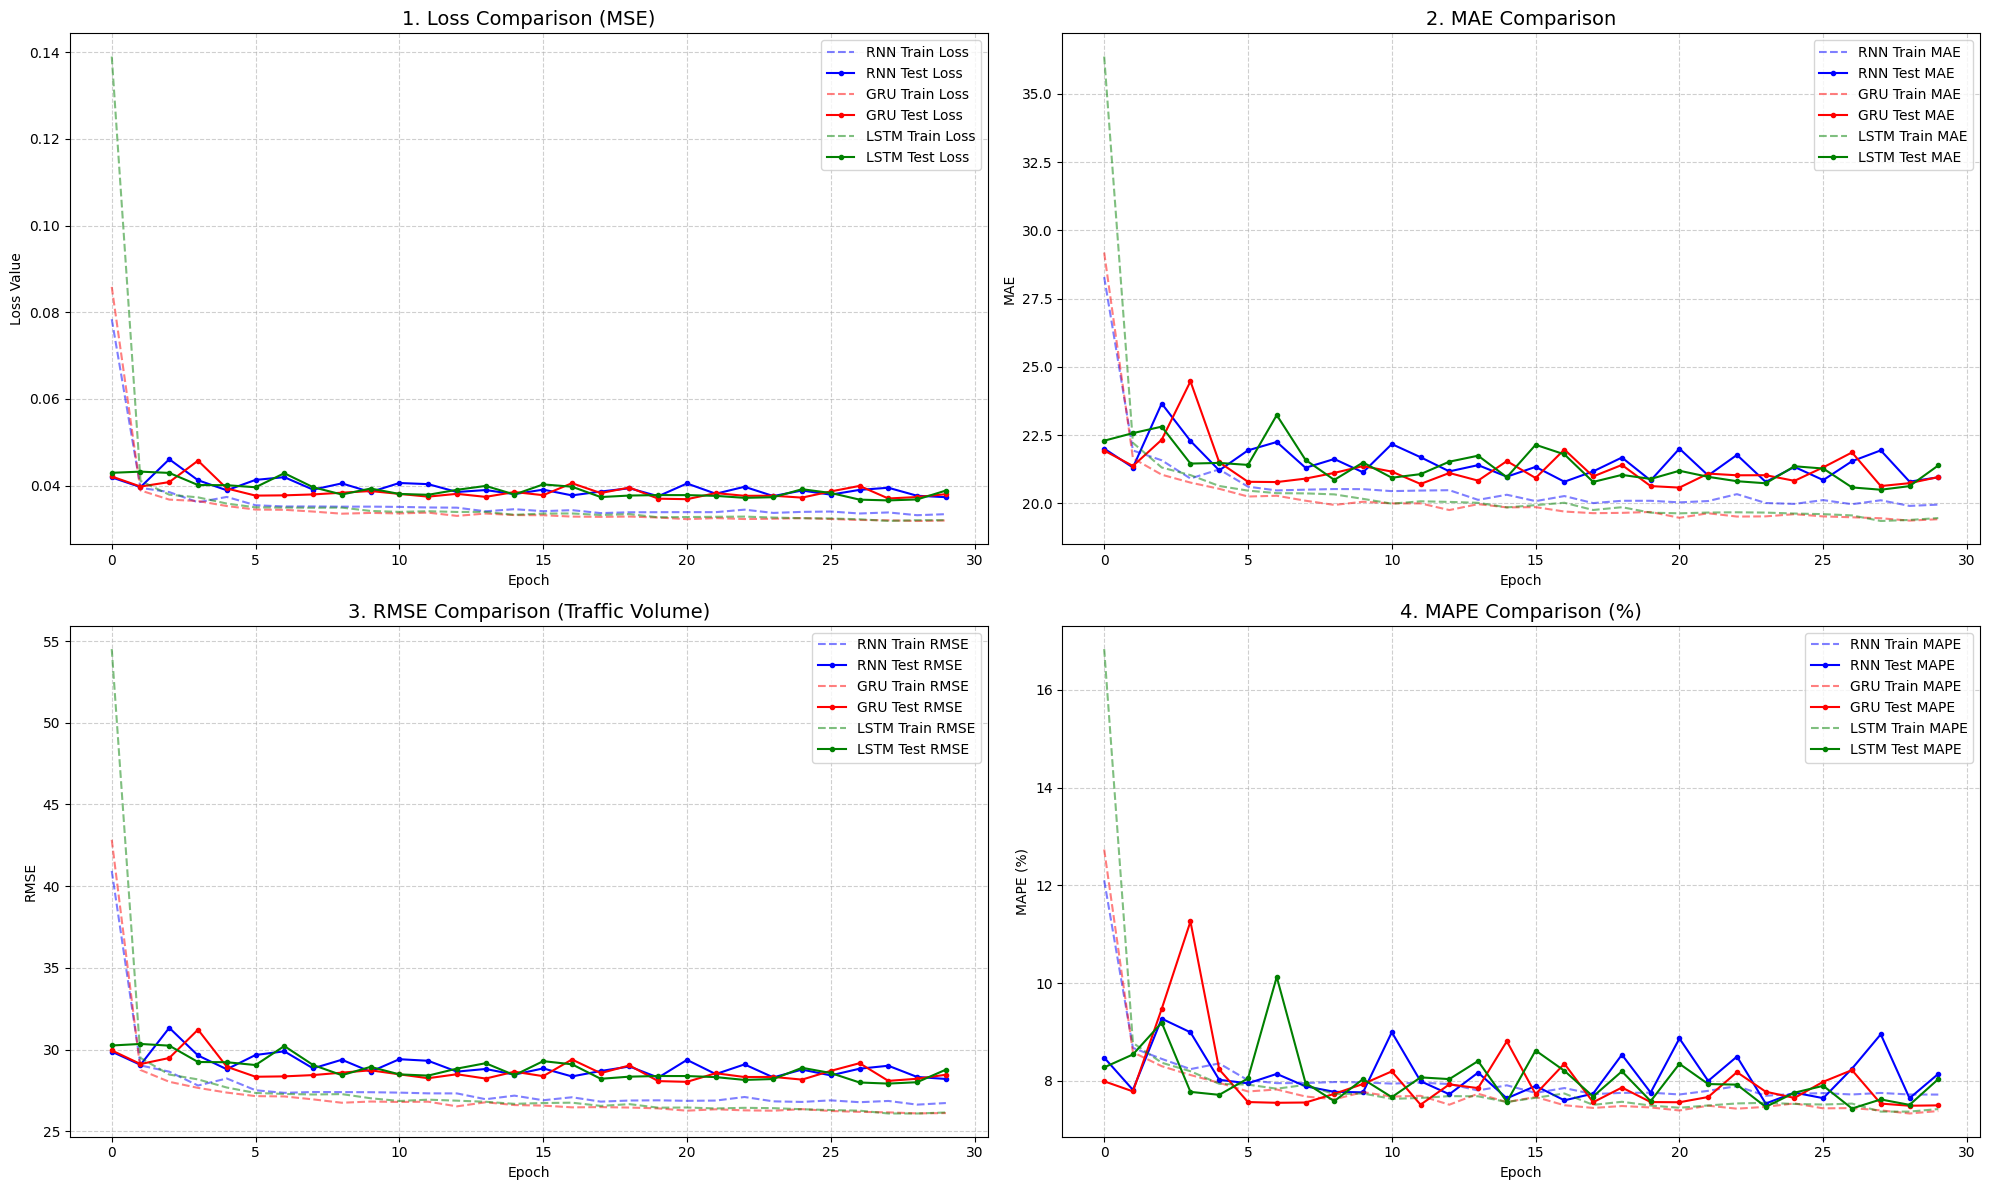

In [6]:
# 获取 Epoch 长度 (x轴)
epochs_range = range(len(rnn_history['train_loss']))

# 设置画布大小 (宽20, 高12)
plt.figure(figsize=(20, 12))

# 定义颜色和标签
colors = {
    'RNN': 'blue',
    'GRU': 'red',
    'LSTM': 'green'
}

# --- 子图 1: Loss 对比 ---
plt.subplot(2, 2, 1)

# RNN (蓝色)
plt.plot(epochs_range, rnn_history['train_loss'], color=colors['RNN'], linestyle='--', alpha=0.5, label='RNN Train Loss')
plt.plot(epochs_range, rnn_history['test_loss'], color=colors['RNN'], linestyle='-', marker='.', label='RNN Test Loss')

# GRU (红色)
plt.plot(epochs_range, gru_history['train_loss'], color=colors['GRU'], linestyle='--', alpha=0.5, label='GRU Train Loss')
plt.plot(epochs_range, gru_history['test_loss'], color=colors['GRU'], linestyle='-', marker='.', label='GRU Test Loss')

# LSTM (绿色)
plt.plot(epochs_range, lstm_history['train_loss'], color=colors['LSTM'], linestyle='--', alpha=0.5, label='LSTM Train Loss')
plt.plot(epochs_range, lstm_history['test_loss'], color=colors['LSTM'], linestyle='-', marker='.', label='LSTM Test Loss')

plt.title("1. Loss Comparison (MSE)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- 子图 2: MAE 对比 ---
plt.subplot(2, 2, 2)

# RNN (蓝色)
plt.plot(epochs_range, rnn_history['train_mae'], color=colors['RNN'], linestyle='--', alpha=0.5, label='RNN Train MAE')
plt.plot(epochs_range, rnn_history['test_mae'], color=colors['RNN'], linestyle='-', marker='.', label='RNN Test MAE')

# GRU (红色)
plt.plot(epochs_range, gru_history['train_mae'], color=colors['GRU'], linestyle='--', alpha=0.5, label='GRU Train MAE')
plt.plot(epochs_range, gru_history['test_mae'], color=colors['GRU'], linestyle='-', marker='.', label='GRU Test MAE')

# LSTM (绿色)
plt.plot(epochs_range, lstm_history['train_mae'], color=colors['LSTM'], linestyle='--', alpha=0.5, label='LSTM Train MAE')
plt.plot(epochs_range, lstm_history['test_mae'], color=colors['LSTM'], linestyle='-', marker='.', label='LSTM Test MAE')

plt.title("2. MAE Comparison", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- 子图 3: RMSE 对比 ---
plt.subplot(2, 2, 3)

# RNN (蓝色)
plt.plot(epochs_range, rnn_history['train_rmse'], color=colors['RNN'], linestyle='--', alpha=0.5, label='RNN Train RMSE')
plt.plot(epochs_range, rnn_history['test_rmse'], color=colors['RNN'], linestyle='-', marker='.', label='RNN Test RMSE')

# GRU (红色)
plt.plot(epochs_range, gru_history['train_rmse'], color=colors['GRU'], linestyle='--', alpha=0.5, label='GRU Train RMSE')
plt.plot(epochs_range, gru_history['test_rmse'], color=colors['GRU'], linestyle='-', marker='.', label='GRU Test RMSE')

# LSTM (绿色)
plt.plot(epochs_range, lstm_history['train_rmse'], color=colors['LSTM'], linestyle='--', alpha=0.5, label='LSTM Train RMSE')
plt.plot(epochs_range, lstm_history['test_rmse'], color=colors['LSTM'], linestyle='-', marker='.', label='LSTM Test RMSE')

plt.title("3. RMSE Comparison (Traffic Volume)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- 子图 4: MAPE 对比 ---
plt.subplot(2, 2, 4)

# RNN (蓝色)
plt.plot(epochs_range, rnn_history['train_mape'], color=colors['RNN'], linestyle='--', alpha=0.5, label='RNN Train MAPE')
plt.plot(epochs_range, rnn_history['test_mape'], color=colors['RNN'], linestyle='-', marker='.', label='RNN Test MAPE')

# GRU (红色)
plt.plot(epochs_range, gru_history['train_mape'], color=colors['GRU'], linestyle='--', alpha=0.5, label='GRU Train MAPE')
plt.plot(epochs_range, gru_history['test_mape'], color=colors['GRU'], linestyle='-', marker='.', label='GRU Test MAPE')

# LSTM (绿色)
plt.plot(epochs_range, lstm_history['train_mape'], color=colors['LSTM'], linestyle='--', alpha=0.5, label='LSTM Train MAPE')
plt.plot(epochs_range, lstm_history['test_mape'], color=colors['LSTM'], linestyle='-', marker='.', label='LSTM Test MAPE')

plt.title("4. MAPE Comparison (%)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MAPE (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

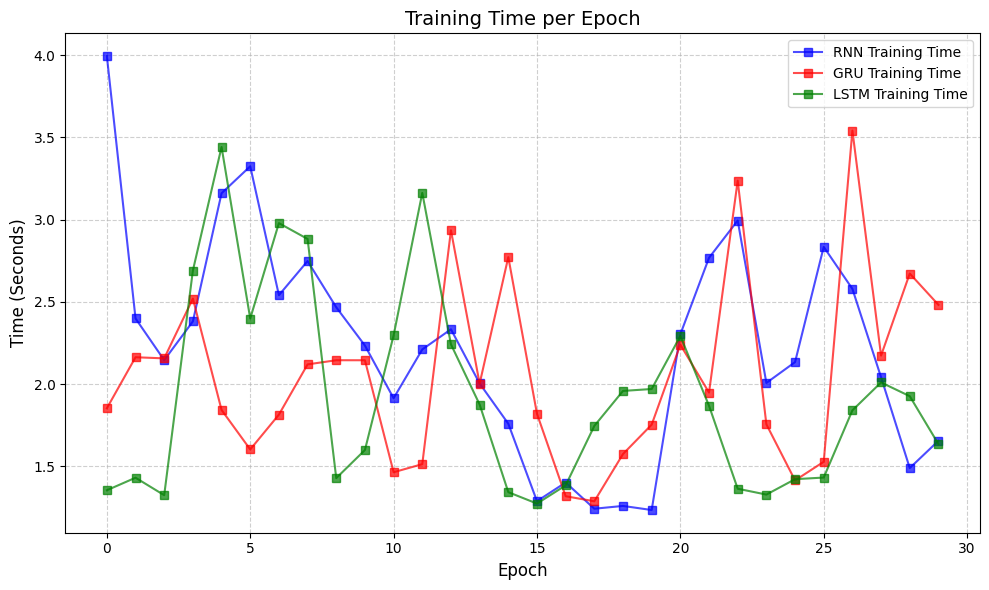

In [7]:
epochs_range = range(len(rnn_history['train_loss']))

# 设置画布大小 (宽20, 高12)
plt.figure(figsize=(10, 6))

# 绘制 RNN、GRU 和 LSTM 的训练时间
plt.plot(epochs_range, rnn_history['time'], color='blue', marker='s', label='RNN Training Time', alpha=0.7)
plt.plot(epochs_range, gru_history['time'], color='red', marker='s', label='GRU Training Time', alpha=0.7)
plt.plot(epochs_range, lstm_history['time'], color='green', marker='s', label='LSTM Training Time', alpha=0.7)

# 设置标题和标签
plt.title("Training Time per Epoch", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Time (Seconds)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

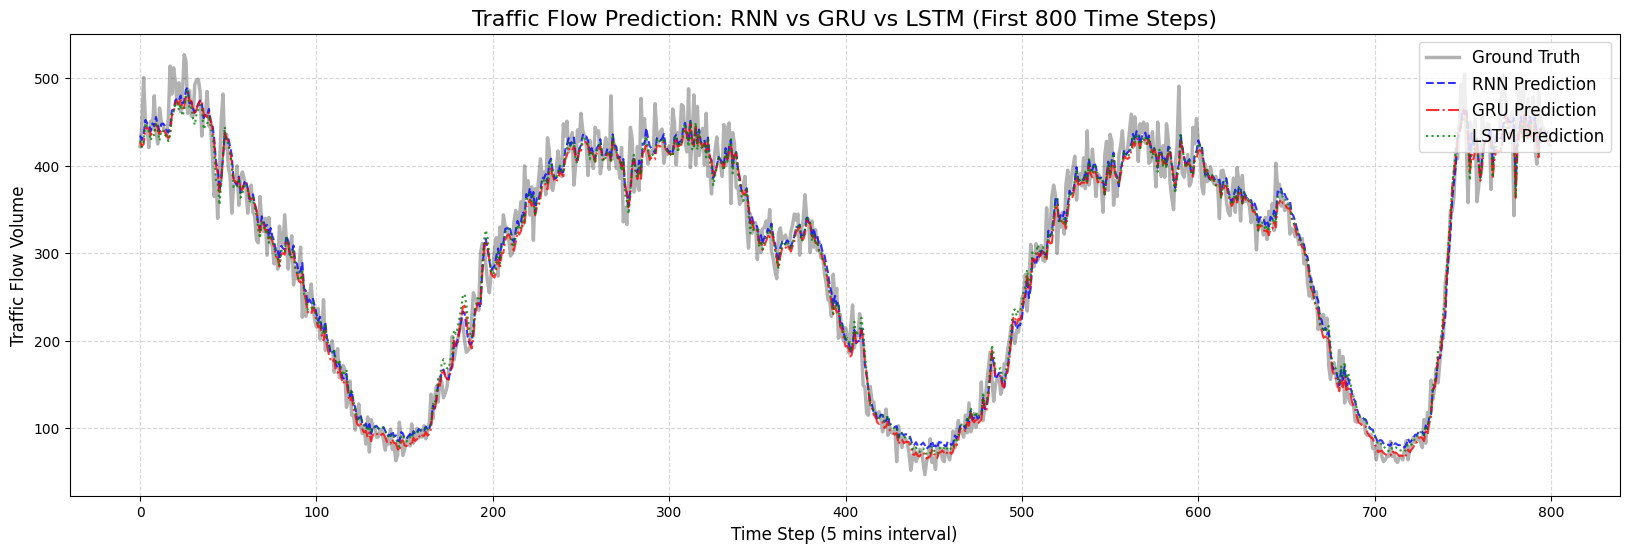

In [8]:
model_rnn.eval()
model_gru.eval()
model_lstm.eval()  # 添加LSTM评估模式

# 将 numpy 测试集转为 tensor 并放入 GPU
test_x_tensor = torch.FloatTensor(test_x).to(device)

with torch.no_grad():
    # 获取归一化的预测值
    pred_rnn_norm = model_rnn(test_x_tensor).cpu().numpy()
    pred_gru_norm = model_gru(test_x_tensor).cpu().numpy()
    pred_lstm_norm = model_lstm(test_x_tensor).cpu().numpy()  # 添加LSTM预测

# 1. 还原 RNN 预测
dummy_rnn = np.zeros((len(pred_rnn_norm), 3))
dummy_rnn[:, 0] = pred_rnn_norm.flatten()
rnn_traffic = scaler.inverse_transform(dummy_rnn)[:, 0]

# 2. 还原 GRU 预测
dummy_gru = np.zeros((len(pred_gru_norm), 3))
dummy_gru[:, 0] = pred_gru_norm.flatten()
gru_traffic = scaler.inverse_transform(dummy_gru)[:, 0]

# 3. 还原 LSTM 预测
dummy_lstm = np.zeros((len(pred_lstm_norm), 3))
dummy_lstm[:, 0] = pred_lstm_norm.flatten()
lstm_traffic = scaler.inverse_transform(dummy_lstm)[:, 0]

# 4. 还原真实值 (test_y)
dummy_true = np.zeros((len(test_y), 3))
dummy_true[:, 0] = test_y.flatten()
real_traffic = scaler.inverse_transform(dummy_true)[:, 0]

plt.figure(figsize=(20, 6))

# 设置显示范围 (前 800 个点，约 2.5 天)
display_len = 800 

# 绘制真实值 (灰色背景)
plt.plot(real_traffic[:display_len], label='Ground Truth', color='black', alpha=0.3, linewidth=2.5)

# 绘制 RNN (蓝色)
plt.plot(rnn_traffic[:display_len], label='RNN Prediction', color='blue', linestyle='--', linewidth=1.5, alpha=0.8)

# 绘制 GRU (红色)
plt.plot(gru_traffic[:display_len], label='GRU Prediction', color='red', linestyle='-.', linewidth=1.5, alpha=0.8)

# 绘制 LSTM (绿色)
plt.plot(lstm_traffic[:display_len], label='LSTM Prediction', color='green', linestyle=':', linewidth=1.5, alpha=0.8)

plt.title(f"Traffic Flow Prediction: RNN vs GRU vs LSTM (First {display_len} Time Steps)", fontsize=16)
plt.xlabel("Time Step (5 mins interval)", fontsize=12)
plt.ylabel("Traffic Flow Volume", fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.show()